In [1]:
import torch
import ultralytics
import cv2
import os
import json
from ultralytics import YOLO  
from pathlib import Path
from joblib import load
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os
import joblib
from joblib import dump



## Distance

In [2]:
import pandas as pd
import re
import os

def parse_filename(filename):
    """
    Extrait l'angle (float), la distance (float) et la personne (int) du nom de fichier
    au format 'angle-distance-Px.txt', où angle et distance peuvent être décimaux.
    """
    match = re.match(r'([\d.]+)-([\d.]+)\.txt', filename)
    if match:
        angle, distance = match.groups()
        return float(angle), float(distance)
    return None, None

def load_yolo_labels_from_folder(folder_path):
    """Charge tous les fichiers YOLO d'un dossier et retourne une DataFrame avec les colonnes demandées."""
    column_names = ["x",	"y",	"w",	"h",	"Cx",	"Cy",	"W",	"H",	"distance",	"angle",	"x_center",	"y2","y_low"]
    
    data = []
    
    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):
            filepath = os.path.join(folder_path, filename)
            angle, distance = parse_filename(filename)
            
            with open(filepath, 'r') as file:
                for line in file:
                    values = list(map(float, line.split()))
                    if len(values) >= 5:  # YOLO format : class x_center y_center width height
                        _, x, y, width, height = values[:5]  # On ignore class_id
                        cx = x * 5376
                        cy= y * 2688
                        cwidth = width * 5376
                        cheight = height * 2688
                        x_center = cx - 5376 / 2
                        low_y = 2688-(cy + cheight / 2)
                        y_low=y-height/2
                        distance=distance
                   
                        
                        row = [x,y,width,height,cx,cy,cwidth,cheight,distance,angle,x_center,low_y,y_low]
                        data.append(row)

    return pd.DataFrame(data, columns=column_names)


# Exemple d'utilisation
second_exp= load_yolo_labels_from_folder("/Users/martin.dejaeghere/Position_Estimation/escooter/labels-studio")
second_exp=second_exp.loc[second_exp['distance'] <= 2400]

thredshold_dist=1000

second_exp_small=second_exp.loc[second_exp['distance'] <= thredshold_dist]
second_exp_big=second_exp.loc[second_exp['distance'] >= thredshold_dist]

def compute_angle_from_normalized_bbox(x_center_norm, image_width):
    """
    Converts a normalized x_center to relative angle in degrees
    """
   
    angle_raw = (x_center_norm / image_width) * 360
    relative_angle = (angle_raw) % 360

    if relative_angle > 180:
        relative_angle -= 360

    return relative_angle



second_exp_small['angle'] = second_exp_small['x_center'].apply(lambda x: compute_angle_from_normalized_bbox(x, 5376))
second_exp_big['angle'] = second_exp_big['x_center'].apply(lambda x: compute_angle_from_normalized_bbox(x, 5376))



/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_54729/3597724341.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  second_exp_small['angle'] = second_exp_small['x_center'].apply(lambda x: compute_angle_from_normalized_bbox(x, 5376))
/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T/ipykernel_54729/3597724341.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  second_exp_big['angle'] = second_exp_big['x_center'].apply(lambda x: compute_angle_from_normalized_bbox(x, 5376))


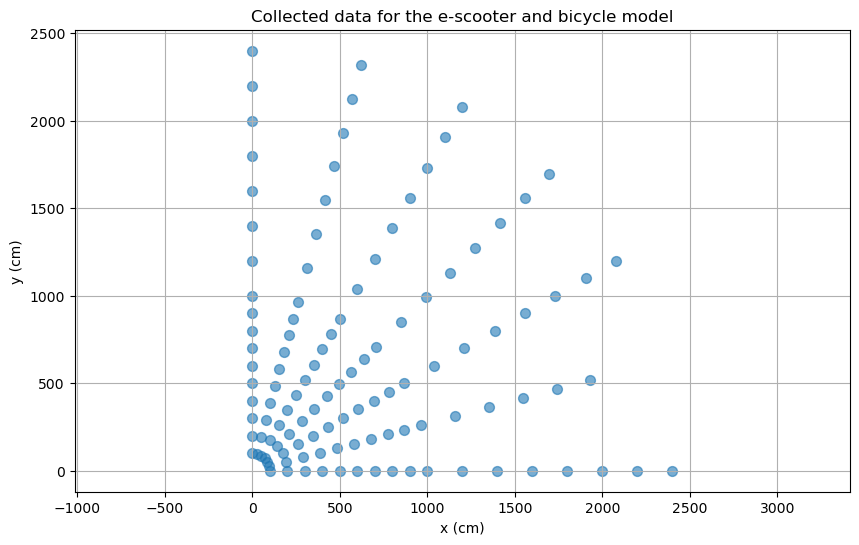

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Conversion en radians
second_exp['angle_rad'] = np.radians(second_exp['angle']).astype(np.float32)

# Conversion polaire → cartésien
second_exp['x'] = second_exp['distance'] * np.sin(second_exp['angle_rad'])
second_exp['y'] = second_exp['distance'] * np.cos(second_exp['angle_rad'])

# Tracer les points
plt.figure(figsize=(10, 6))
plt.scatter(second_exp['x'], second_exp['y'], alpha=0.6, s=50)  # Augmentation de la taille des points
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
plt.title('Collected data for the e-scooter and bicycle model')
plt.grid(True)
plt.axis('equal')  # Échelle équivalente sur x et y
plt.show()

Split 1: 14/56 = 0.250
Split 2: 14/56 = 0.250
Split 3: 14/56 = 0.250
Split 4: 14/56 = 0.250
Split 5: 14/56 = 0.250
Split 6: 14/56 = 0.250
Split 7: 14/56 = 0.250
Split 8: 14/56 = 0.250
Split 9: 14/56 = 0.250
Split 10: 14/56 = 0.250
R²: -0.1243, RMSE: 159.05
R²: -1.3453, RMSE: 153.14
R²: -1.6120, RMSE: 161.62
R²: 0.9419, RMSE: 72.32
R²: 0.3717, RMSE: 198.17
R²: 0.8236, RMSE: 84.01
R²: 0.1748, RMSE: 136.26
R²: 0.7455, RMSE: 201.80
R²: 0.3717, RMSE: 198.17
R²: 0.6068, RMSE: 219.48
Ordre 1: R² moyen = 0.0954, RMSE moyen = 158.40
R²: 0.8304, RMSE: 61.78
R²: -0.4262, RMSE: 119.42
R²: 0.2355, RMSE: 87.44
R²: 0.8293, RMSE: 123.94
R²: 0.8153, RMSE: 107.45
R²: 0.5799, RMSE: 129.63
R²: 0.8089, RMSE: 65.57
R²: 0.8914, RMSE: 131.79
R²: 0.8153, RMSE: 107.45
R²: 0.9116, RMSE: 104.08
Ordre 2: R² moyen = 0.6291, RMSE moyen = 103.86
R²: 0.9191, RMSE: 42.66
R²: 0.9502, RMSE: 22.31
R²: 0.8443, RMSE: 39.46
R²: 0.9950, RMSE: 21.28
R²: 0.9513, RMSE: 55.19
R²: 0.9585, RMSE: 40.75
R²: 0.9569, RMSE: 31.12
R²: 0.

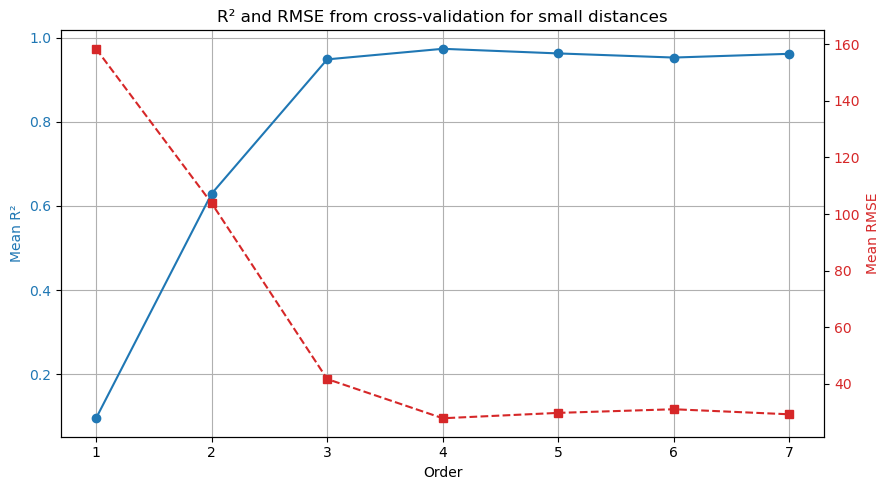

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# (Assuming second_exp_small is already defined)
# Définir 10 paires de distances pour les splits
dist_pairs = [
    [300, 600],
    [200, 400],
    [600, 400],
    [800, 200],
    [500, 1000],
    [200, 600],
    [400, 700],
    [1000, 200],
    [1000, 500],
    [1000, 300]
]
splits = []

for pair in dist_pairs:
    test_data = second_exp_small.loc[second_exp_small['distance'].isin(pair)]
    training_data = second_exp_small.loc[~second_exp_small['distance'].isin(pair)]
    splits.append((training_data, test_data))

# Vérifier les ratios test/train
for i, (train, test) in enumerate(splits, 1):
    print(f"Split {i}: {len(test)}/{len(train)} = {len(test)/len(train):.3f}")

# Évaluation
def evaluate_polynomial_regression(splits, order):
    r2_dist_scores, rmse_scores = [], []

    for training_data_small, test_data_small in splits:
        X_train = training_data_small[["y2"]].astype(int).values
        y_dist_train = training_data_small["distance"].round(1).values.flatten()

        X_test = test_data_small[["y2"]].astype(int).values
        y_dist_test = test_data_small["distance"].round(1).values.flatten()

        poly = PolynomialFeatures(degree=order)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        model_dist = LinearRegression().fit(X_train_poly, y_dist_train)
        y_dist_pred = model_dist.predict(X_test_poly)

        r2_dist = r2_score(y_dist_test, y_dist_pred)
        rmse = np.sqrt(mean_squared_error(y_dist_test, y_dist_pred))

        r2_dist_scores.append(r2_dist)
        rmse_scores.append(rmse)
        print(f"R²: {r2_dist:.4f}, RMSE: {rmse:.2f}")

    return np.mean(r2_dist_scores), np.mean(rmse_scores)

# Itération sur les ordres
orders = range(1, 8)
r2_values = []
rmse_values = []

for order in orders:
    r2_moyen, rmse_moyen = evaluate_polynomial_regression(splits, order)
    r2_values.append(r2_moyen)
    rmse_values.append(rmse_moyen)
    print(f"Ordre {order}: R² moyen = {r2_moyen:.4f}, RMSE moyen = {rmse_moyen:.2f}")


best_degree_small_dist = orders[np.argmax(r2_values)]

# Affichage du graphique
fig, ax1 = plt.subplots(figsize=(9, 5))

color = 'tab:blue'
ax1.set_xlabel("Order")
ax1.set_ylabel("Mean R²", color=color)
ax1.plot(orders, r2_values, marker='o', color=color, label='R² mean')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

# Second y-axis for RMSE
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel("Mean RMSE", color=color)
ax2.plot(orders, rmse_values, marker='s', linestyle='--', color=color, label='RMSE mean')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("R² and RMSE from cross-validation for small distances")
fig.tight_layout()
plt.show()


Split 1: 10/50 = 0.200
Split 2: 10/50 = 0.200
Split 3: 10/50 = 0.200
Split 4: 10/50 = 0.200
Split 5: 10/51 = 0.196
Split 6: 10/51 = 0.196
Split 7: 10/51 = 0.196
Split 8: 10/50 = 0.200
Split 9: 10/50 = 0.200
Split 10: 10/50 = 0.200
0.9680369467451773 70.06800253996666
0.6505400037410376 118.23028313574528
0.9211529647200306 82.53716646571625
0.9680369467451773 70.06800253996666
0.8592320687901052 110.28304156367338
0.8894601677994647 228.0305616954267
0.8260132814928287 83.42343040349546
0.6821662763106706 112.75348751844962
0.8811103373053938 101.35120550251969
0.6212566358815419 241.19490195399067
Ordre 1: R² moyen = 0.8267, RMSE moyen = 121.79
0.9756930382243391 61.102776767848496
0.9263295181727985 54.28461359435157
0.9646877635959408 55.23565175962637
0.9756930382243391 61.102776767848496
0.9708411134526052 50.19290585027846
0.9839886883741532 86.78548835374676
0.944930715639532 46.933691250728614
0.9448270080607769 46.97786369737267
0.9720168479582091 49.17056371865929
0.975364402

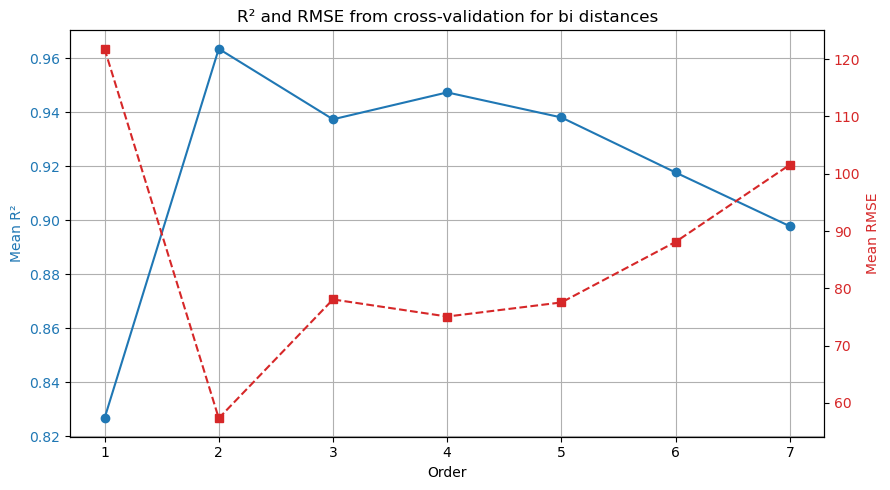

In [84]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# (Assuming second_exp_small is already defined)

# Définir les 10 splits
dist_pairs = [
    [1200, 2000],
    [1800, 1400],
    [1200, 1800],
    [2000, 1200],
    [1600, 2200],
    [1000, 2400],
    [1800, 2200],
    [1200, 1600],
    [1400, 2000],
    [1000, 1800]
]

splits = []

for pair in dist_pairs:
    test_data = second_exp_big.loc[second_exp_big['distance'].isin(pair)].head(10)
    training_data = second_exp_big.loc[~second_exp_big['distance'].isin(pair)]
    splits.append((training_data, test_data))

# Vérifier les ratios test/train
for i, (train, test) in enumerate(splits, 1):
    print(f"Split {i}: {len(test)}/{len(train)+len(test)} = {len(test)/(len(train)+len(test)):.3f}")

# Évaluation
def evaluate_polynomial_regression(splits, order):
    r2_dist_scores, rmse_scores = [], []

    for training_data_small, test_data_small in splits:
        X_train = training_data_small[["x_center", "y2"]].astype(int).values
        y_dist_train = training_data_small["distance"].round(1).values.flatten()

        X_test = test_data_small[["x_center", "y2"]].astype(int).values
        y_dist_test = test_data_small["distance"].round(1).values.flatten()

        poly = PolynomialFeatures(degree=order)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        model_dist = LinearRegression().fit(X_train_poly, y_dist_train)
        y_dist_pred = model_dist.predict(X_test_poly)

        r2_dist = r2_score(y_dist_test, y_dist_pred)
        rmse = np.sqrt(mean_squared_error(y_dist_test, y_dist_pred))
        print(r2_dist, rmse)

        r2_dist_scores.append(r2_dist)
        rmse_scores.append(rmse)

    return np.mean(r2_dist_scores), np.mean(rmse_scores)

# Itération sur les ordres
orders = range(1, 8)
r2_values = []
rmse_values = []

for order in orders:
    r2_moyen, rmse_moyen = evaluate_polynomial_regression(splits, order)
    r2_values.append(r2_moyen)
    rmse_values.append(rmse_moyen)
    print(f"Ordre {order}: R² moyen = {r2_moyen:.4f}, RMSE moyen = {rmse_moyen:.2f}")


best_degree_big_dist = orders[np.argmin(rmse_values)]

# Affichage du graphique
fig, ax1 = plt.subplots(figsize=(9, 5))

color = 'tab:blue'
ax1.set_xlabel("Order")
ax1.set_ylabel("Mean R²", color=color)
ax1.plot(orders, r2_values, marker='o', color=color, label='R² mean')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

# Second y-axis for RMSE
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel("Mean RMSE", color=color)
ax2.plot(orders, rmse_values, marker='s', linestyle='--', color=color, label='RMSE mean')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("R² and RMSE from cross-validation for bi distances")
fig.tight_layout()
plt.show()


In [38]:
evaluate_polynomial_regression(splits, 2)

0.9756930382243391
61.102776767848496
0.9263295181727985
54.28461359435157
0.8523382227813108
38.426784567367754
0.894322653644573
63.702512509699325
0.9708411134526052
50.19290585027846


(0.9239049092551251, 53.541918657909115)

## Cross-validation angle

In [39]:
calibration_values_angle = pd.DataFrame(second_exp[["x_center"]]).astype(int)
angle_values_angle = pd.DataFrame(second_exp["angle"]).round(1)
distance_values_angle = pd.DataFrame(second_exp["distance"]).round(1)


calibration_values_angle = calibration_values_angle.astype(float)
angle_values_angle = angle_values_angle.astype(float)


Ordre 1: R² moyen = 0.9907, RMSE moyen = 2.07
Ordre 2: R² moyen = 0.9898, RMSE moyen = 2.28
Ordre 3: R² moyen = 0.9780, RMSE moyen = 3.46
Ordre 4: R² moyen = 0.9516, RMSE moyen = 5.68
Ordre 5: R² moyen = 0.8251, RMSE moyen = 9.72


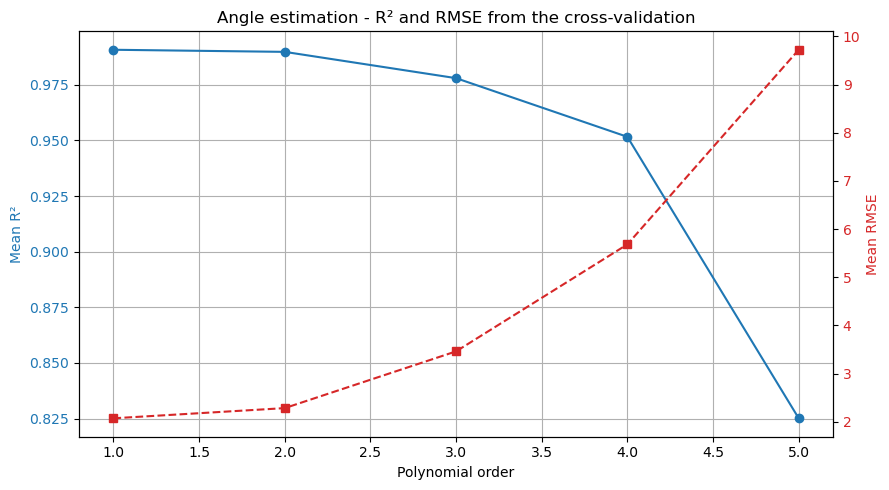

In [40]:
import numpy as np
import pandas as pd

# Exemple : construire un DataFrame de base
df = pd.DataFrame(calibration_values_angle, columns=["x_center", "y2"])
df["angle"] = angle_values_angle['angle'] if hasattr(angle_values_angle, 'columns') else angle_values_angle

# Définir les splits selon des sous-ensembles d’angles
test_angles_sets = [
    [0, 45],
    [15, 60],
    [30, 75],
    [0, 90],
    [15, 45]
]

splits = []

for test_angles in test_angles_sets:
    test_data = df[df["angle"].isin(test_angles)]
    train_data = df[~df["angle"].isin(test_angles)]
    splits.append((train_data, test_data))

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

orders = range(1, 6)
r2_means = []
rmse_means = []

for order in orders:
    r2_list, rmse_list = [], []

    for train_data, test_data in splits:
        X_train = train_data[["x_center"]].astype(float).values
        y_train = train_data["angle"].astype(float).values

        X_test = test_data[["x_center"]].astype(float).values
        y_test = test_data["angle"].astype(float).values

        poly = PolynomialFeatures(degree=order)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        model = LinearRegression().fit(X_train_poly, y_train)
        y_pred = model.predict(X_test_poly)

        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        r2_list.append(r2)
        rmse_list.append(rmse)

    r2_means.append(np.mean(r2_list))
    rmse_means.append(np.mean(rmse_list))
    print(f"Ordre {order}: R² moyen = {np.mean(r2_list):.4f}, RMSE moyen = {np.mean(rmse_list):.2f}")

    # Plot R² et RMSE
fig, ax1 = plt.subplots(figsize=(9, 5))

best_degree_ang = orders[np.argmax(r2_means)]

ax1.set_xlabel("Polynomial order")
ax1.set_ylabel("Mean R²", color='tab:blue')
ax1.plot(orders, r2_means, marker='o', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.set_ylabel("Mean RMSE", color='tab:red')
ax2.plot(orders, rmse_means, marker='s', linestyle='--', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title("Angle estimation - R² and RMSE from the cross-validation")
fig.tight_layout()
plt.show()



## Model

In [41]:
calibration_values_small = pd.DataFrame(second_exp_small[["x_center", "y2",]]).astype(int)
angle_values_small = pd.DataFrame(second_exp_small["angle"]).round(1)
distance_values_small = pd.DataFrame(second_exp_small["distance"]).round(1)

calibration_values_big = pd.DataFrame(second_exp_big[["x_center", "y2"]]).astype(int)
angle_values_big = pd.DataFrame(second_exp_big["angle"]).round(1)
distance_values_big = pd.DataFrame(second_exp_big["distance"]).round(1)

calibration_values = pd.DataFrame(second_exp[["x_center"]]).astype(int)
angle_values = pd.DataFrame(second_exp["angle"]).round(1)
distance_values = pd.DataFrame(second_exp["distance"]).round(1)


In [55]:
import matplotlib.pyplot as plt
import numpy as np

dist_pr = PolynomialFeatures(degree=4)

x_train_pr = dist_pr.fit_transform(calibration_values_small)


# Fitting the polynomial equation for the distance
poly_dist = LinearRegression()
poly_dist.fit(x_train_pr, distance_values_small)

# Sauvegarde du modèle de distance
joblib.dump((dist_pr, poly_dist), 'distance_predictor_small.joblib')





# Fit a model of order 4 for angle
angle_pr = PolynomialFeatures(degree=1)

x_train_pr = angle_pr.fit_transform(calibration_values)


# Fitting the polynomial equation for the angles
poly_angular = LinearRegression()
poly_angular.fit(x_train_pr, angle_values)
# Sauvegarde du modèle d'angle
joblib.dump((angle_pr, poly_angular), 'angle_predictor.joblib')



dist_pr = PolynomialFeatures(degree=2)

x_train_pr = dist_pr.fit_transform(calibration_values_big)

# Fitting the polynomial equation for the distance
poly_dist = LinearRegression()
poly_dist.fit(x_train_pr, distance_values_big)


# Sauvegarde du modèle de distance
joblib.dump((dist_pr, poly_dist), 'distance_predictor_big.joblib')




['distance_predictor_big.joblib']

In [56]:
import joblib
def dist_est(c_x, c_y):
    distance_features, distance_model = joblib.load('/Users/martin.dejaeghere/Position_Estimation/escooter/distance_predictor_small.joblib')
    image_data =pd.DataFrame([[c_x, c_y]], columns=["x_center", "y2"])
    cur_dist = distance_model.predict(distance_features.transform(image_data))[0][0]
    if cur_dist >thredshold_dist-10:
        distance_features, distance_model = joblib.load('/Users/martin.dejaeghere/Position_Estimation/escooter/distance_predictor_big.joblib')
        image_data =pd.DataFrame([[c_x, c_y]], columns=["x_center", "y2"])
        cur_dist = distance_model.predict(distance_features.transform(image_data))[0][0]
 
    return cur_dist if 0 <= cur_dist <= 2400 else float('inf')

def ang_est(c_x):
    angle_features, angle_model = joblib.load('/Users/martin.dejaeghere/Position_Estimation/escooter/angle_predictor.joblib')
    image_data =pd.DataFrame([[c_x]], columns=["x_center"])

    cur_angle = angle_model.predict(angle_features.transform(image_data))[0][0]
    return cur_angle if -10 <= cur_angle <= 90 else float('inf')

def get_ang_dist(c_x, c_y):
    width = 5376
    segment = width / 4  # 1344

    if 0 < c_x < segment:
        cur_dist = dist_est(c_x, c_y)
        cur_ang = ang_est(c_x)

    elif segment <= c_x < 2 * segment:
        c_x -= segment
        cur_dist = dist_est(c_x, c_y)
        cur_ang = ang_est(c_x)
        cur_ang += 90



    elif -segment < c_x < 0:
        c_x = -c_x
        cur_dist = dist_est(c_x, c_y)
        cur_ang = ang_est(c_x)
        cur_ang = -cur_ang

    elif -2 * segment < c_x <= -segment:
        c_x = -c_x - segment
        cur_dist = dist_est(c_x, c_y)
        cur_ang = ang_est(c_x)
        cur_ang = -cur_ang - 90

 

    else:
        cur_dist = float('inf')
        cur_ang = float('inf')

    return cur_ang, cur_dist


# Change this and check if the output is correct:
c_x = 239.140137  
c_y = 566
cur_angle,cur_dist = get_ang_dist(c_x, c_y)

print(f"Distance: {cur_dist}")
print(f"Angle: {cur_angle}")

Distance: 191.32737374939006
Angle: 17.037745608438673


## Validation

In [57]:
model = YOLO("/Users/martin.dejaeghere/Library/CloudStorage/OneDrive-Chalmers/Fichiers de Marco Dozza - MicroSINT/03 - Models/Road-user identification/MicroVision-Chalmers-x-20250304.pt")
classes = ["pedestrians", "bikes", "bicyclists", "e-scooters", "e-scooterists"]

# Dossier contenant les images
image_dir = "/Users/martin.dejaeghere/Position_Estimation/escooter/validation/images"
output_images_dir = "validation/output_images"
output_labels_dir = "validation/output_labels"
os.makedirs(output_images_dir, exist_ok=True)
os.makedirs(output_labels_dir, exist_ok=True)

# Traiter chaque image dans le dossier
for image_name in os.listdir(image_dir):
    image_path = os.path.join(image_dir, image_name)
    image = cv2.imread(image_path)
    if image is None:
        continue  # Ignorer les fichiers non valides

    # Exécuter la détection YOLO
    results = model.predict(image, iou=0.45, imgsz=1280, conf=0.3,classes=4)
    
    # Annoter l'image
    annotated_image = results[0].plot()
    
    # Sauvegarder l'image annotée
    output_image_path = os.path.join(output_images_dir, image_name)
    cv2.imwrite(output_image_path, annotated_image)
    
    # Sauvegarder les labels au format YOLO
    label_filename = os.path.splitext(image_name)[0] + ".txt"
    label_path = os.path.join(output_labels_dir, label_filename)
    with open(label_path, "w") as f:
        for r in results[0].boxes:
            cls = int(r.cls)
            x_center, y_center, w, h = r.xywhn[0]  # Coordonnées normalisées
            f.write(f"{cls} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n")


0: 640x1280 1 e-scooterist, 878.6ms
Speed: 4.2ms preprocess, 878.6ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 1280)

0: 640x1280 1 e-scooterist, 830.0ms
Speed: 3.1ms preprocess, 830.0ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 1280)

0: 640x1280 1 e-scooterist, 763.0ms
Speed: 3.8ms preprocess, 763.0ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 1280)

0: 640x1280 1 e-scooterist, 781.6ms
Speed: 3.1ms preprocess, 781.6ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 1280)

0: 640x1280 1 e-scooterist, 761.5ms
Speed: 3.2ms preprocess, 761.5ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 1280)

0: 640x1280 1 e-scooterist, 739.1ms
Speed: 3.1ms preprocess, 739.1ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 1280)

0: 640x1280 1 e-scooterist, 742.2ms
Speed: 3.6ms preprocess, 742.2ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 1280)

0: 640x1280 1 e-scooterist, 793.9ms
Speed: 3.2m

In [58]:
from math import sqrt, atan2, degrees

def parse_filename(filename):
    """
    Extrait l'angle (float), la distance (float) et la personne (int) du nom de fichier
    au format 'angle-distance-Px.txt', où angle et distance peuvent être décimaux.
    """
    match = re.match(r'([\d.]+)-([\d.]+)-S(\d+)\.txt', filename)
    if match:
        x, y, person = match.groups()
        return float(x), float(y)
    return None, None

def load_yolo_labels_from_folder(folder_path):
    """Charge tous les fichiers YOLO d'un dossier et retourne une DataFrame avec les colonnes demandées."""
    column_names = ["x",	"y",	"w",	"h",	"Cx",	"Cy",	"W",	"H",	"distance",	"angle",	"x_center",	"y2","y_low"]
    
    data = []
    
    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):
            filepath = os.path.join(folder_path, filename)
            x, y = parse_filename(filename)
            distance=sqrt(x**2+y**2)
            angle=degrees(atan2(x, y))
            
            with open(filepath, 'r') as file:
                for line in file:
                    values = list(map(float, line.split()))
                    if len(values) >= 5:  # YOLO format : class x_center y_center width height
                        _, x, y, width, height = values[:5]  # On ignore class_id
                        cx = x * 5376
                        cy= y * 2688
                        cwidth = width * 5376
                        cheight = height * 2688
                        x_center = cx - 5376 / 2
                        low_y = 2688-(cy + cheight / 2)
                        y_low=y-height/2
                        distance=distance*100
                   
                        
                        row = [x,y,width,height,cx,cy,cwidth,cheight,distance,angle,x_center,low_y,y_low]
                        data.append(row)

    return pd.DataFrame(data, columns=column_names)


# Exemple d'utilisation
val= load_yolo_labels_from_folder('/Users/martin.dejaeghere/Position_Estimation/escooter/validation/output_labels')

In [59]:
calibration_test_values=val[["x_center", "y2"]].astype(int)
angle_test_values=pd.DataFrame(val["angle"].round(1))
distance_test_values=pd.DataFrame(val["distance"])

In [60]:
calibration_test_values

,x_center,y2
0,569,1258
1,120,1267
2,208,1263
3,1078,1153
4,1407,1244
5,1079,1147
6,784,1235
7,505,1279


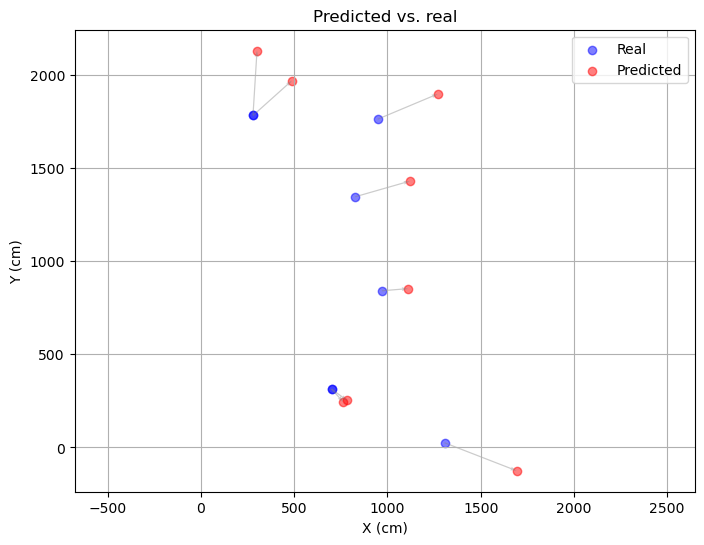

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import joblib

# Charger les modèles et les transformateurs
yhat_ang = []
yhat_dist = []

for _, row in calibration_test_values.iterrows():
    c_x, c_y = row["x_center"], row["y2"]
    ang, dist = get_ang_dist(c_x, c_y)
    ang=compute_angle_from_normalized_bbox(c_x, 5376)
    yhat_ang.append(ang)
    yhat_dist.append(dist)

# Conversion en array NumPy si besoin
yhat_ang = np.array(yhat_ang)
yhat_dist = np.array(yhat_dist)
# Valeurs réelles
true_ang = angle_test_values['angle'].values
true_dist = distance_test_values['distance'].values

# Conversion polaire -> cartésienne
real_x = true_dist * np.sin(np.radians(true_ang))
real_y = true_dist * np.cos(np.radians(true_ang))

pred_x = yhat_dist * np.sin(np.radians(yhat_ang))
pred_y = yhat_dist * np.cos(np.radians(yhat_ang))

# Vecteurs d'erreur (flèches de réel → prédit)
dx = pred_x - real_x
dy = pred_y - real_y

# Tracer les points et les barres d'erreur
plt.figure(figsize=(8, 6))
plt.scatter(real_x, real_y, c='blue', label='Real', alpha=0.5)
plt.scatter(pred_x, pred_y, c='red', label='Predicted', alpha=0.5)
plt.quiver(real_x, real_y, dx, dy, angles='xy', scale_units='xy', scale=1, color='gray', alpha=0.4, width=0.002)

plt.axis('equal')
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')
plt.title("Predicted vs. real")
plt.legend()
plt.grid(True)
plt.show()



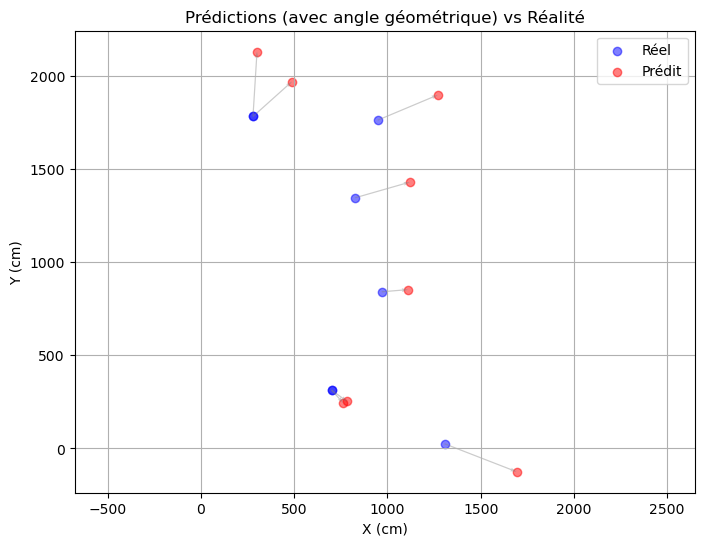

In [62]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures




yhat_ang = []
yhat_dist = []

for _, row in calibration_test_values.iterrows():
    c_x, c_y = row["x_center"], row["y2"]
    ang, dist = get_ang_dist(c_x, c_y)
    yhat_ang.append(ang)
    yhat_dist.append(dist)

# Conversion en array NumPy si besoin
yhat_dist = np.array(yhat_dist)

# Remplacer la prédiction angulaire par le calcul depuis Xc
image_width = 5376  
Xc_test = calibration_test_values['x_center'].values
yhat_ang = np.array([compute_angle_from_normalized_bbox(x, image_width) for x in Xc_test])

# Valeurs réelles
true_ang = angle_test_values['angle'].values
true_dist = distance_test_values['distance'].values

real_x = true_dist * np.sin(np.radians(true_ang))
real_y = true_dist * np.cos(np.radians(true_ang))

pred_x = yhat_dist * np.sin(np.radians(yhat_ang))
pred_y = yhat_dist * np.cos(np.radians(yhat_ang))

# Vecteurs d'erreur (flèches de réel -> prédit)
dx = pred_x - real_x
dy = pred_y - real_y

# Tracé
plt.figure(figsize=(8, 6))

plt.scatter(real_x, real_y, c='blue', label='Réel', alpha=0.5)
plt.scatter(pred_x, pred_y, c='red', label='Prédit', alpha=0.5)
plt.quiver(real_x, real_y, dx, dy, angles='xy', scale_units='xy', scale=1, color='gray', alpha=0.4, width=0.002)

plt.axis('equal')
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')
plt.title("Prédictions (avec angle géométrique) vs Réalité")
plt.legend()
plt.grid(True)
plt.show()


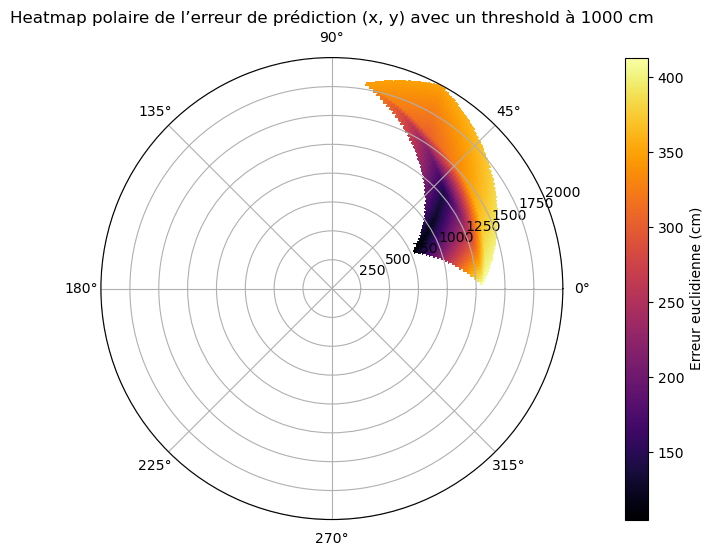

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

yhat_ang = []
yhat_dist = []

for _, row in calibration_test_values.iterrows():
    c_x, c_y = row["x_center"], row["y2"]
    ang, dist = get_ang_dist(c_x, c_y)
    yhat_ang.append(ang)
    yhat_dist.append(dist)

# Conversion en array NumPy si besoin
yhat_ang = np.array(yhat_ang)
yhat_dist = np.array(yhat_dist)

x_vals = calibration_test_values['x_center'].values
y_vals = calibration_test_values['y2'].values

yhat_ang = []
yhat_dist = []

for c_x, c_y in zip(x_vals, y_vals):
    ang, dist = get_ang_dist(c_x, c_y)
    angle=compute_angle_from_normalized_bbox(c_x, 5376)
    yhat_ang.append(angle)
    yhat_dist.append(dist)

yhat_ang = np.array(yhat_ang)
yhat_dist = np.array(yhat_dist)

true_ang = angle_test_values['angle'].values
true_dist = distance_test_values['distance'].values

# Étape 2: conversion en coordonnées cartésiennes
real_x = true_dist * np.sin(np.radians(true_ang))
real_y = true_dist * np.cos(np.radians(true_ang))
pred_x = yhat_dist * np.sin(np.radians(yhat_ang))
pred_y = yhat_dist * np.cos(np.radians(yhat_ang))

# Étape 3: calcul de l’erreur (distance euclidienne)
error = np.sqrt((real_x - pred_x)**2 + (real_y - pred_y)**2)

# Coordonnées polaires basées sur les réels (ou prédits)
theta = np.arctan2(real_y, real_x)
r = np.sqrt(real_x**2 + real_y**2)

# Étape 4: création d'une grille polaire
theta_grid, r_grid = np.meshgrid(
    np.linspace(-np.pi, np.pi, 300),
    np.linspace(min(r), max(r), 300)
)

# Interpolation des erreurs sur la grille
error_grid = griddata(
    points=(theta, r),
    values=error,
    xi=(theta_grid, r_grid),
    method='linear'
)

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 6))
c = ax.pcolormesh(theta_grid, r_grid, error_grid, cmap='inferno', shading='auto')
cb = plt.colorbar(c, ax=ax, orientation='vertical', pad=0.1)
cb.set_label('Erreur euclidienne (cm)')
ax.set_title(f'Heatmap polaire de l’erreur de prédiction (x, y) avec un threshold à {thredshold_dist} cm')
plt.show()

